In [1]:
!pip install pandas numpy scikit-learn xgboost openpyxl joblib



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\DELL\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


--- MODEL TRAINING PERFORMANCE ---

Target: Diabetes_Risk
Train Acc: 0.998 | Test Acc: 0.998 (Gap: 0.000)

Target: Hypertension_Risk
Train Acc: 0.999 | Test Acc: 1.000 (Gap: -0.001)

Target: Heart_Disease_Risk
Train Acc: 1.000 | Test Acc: 1.000 (Gap: 0.000)

Target: Obesity_Risk
Train Acc: 0.999 | Test Acc: 0.999 (Gap: 0.001)

Target: Anemia_Risk
Train Acc: 1.000 | Test Acc: 1.000 (Gap: 0.000)

Target: Kidney_Disease_Risk
Train Acc: 1.000 | Test Acc: 1.000 (Gap: -0.000)

FINAL PREDICTIONS

DETAILED MEDICAL RISK REPORT

>>> Patient 1 ()
Calculated BMI : 29.5
Normal Range   : 18.5 - 24.9
Clinical Status: Overweight (Pre-Obese)
------------------------------
Diabetes Risk       :  MODERATE RISK (40.3%)
Hypertension Risk   :  HIGH RISK (75.7%)
Heart Disease Risk  :  HIGH RISK (59.5%)
Obesity Risk        :  MODERATE RISK (29.0%)
Anemia Risk         :  HIGH RISK (54.0%)
Kidney Disease Risk :  HIGH RISK (62.3%)

>>> Patient 2 (High Risk)
Calculated BMI : 32.9
Normal Range   : 18.5 - 24.9
Clin

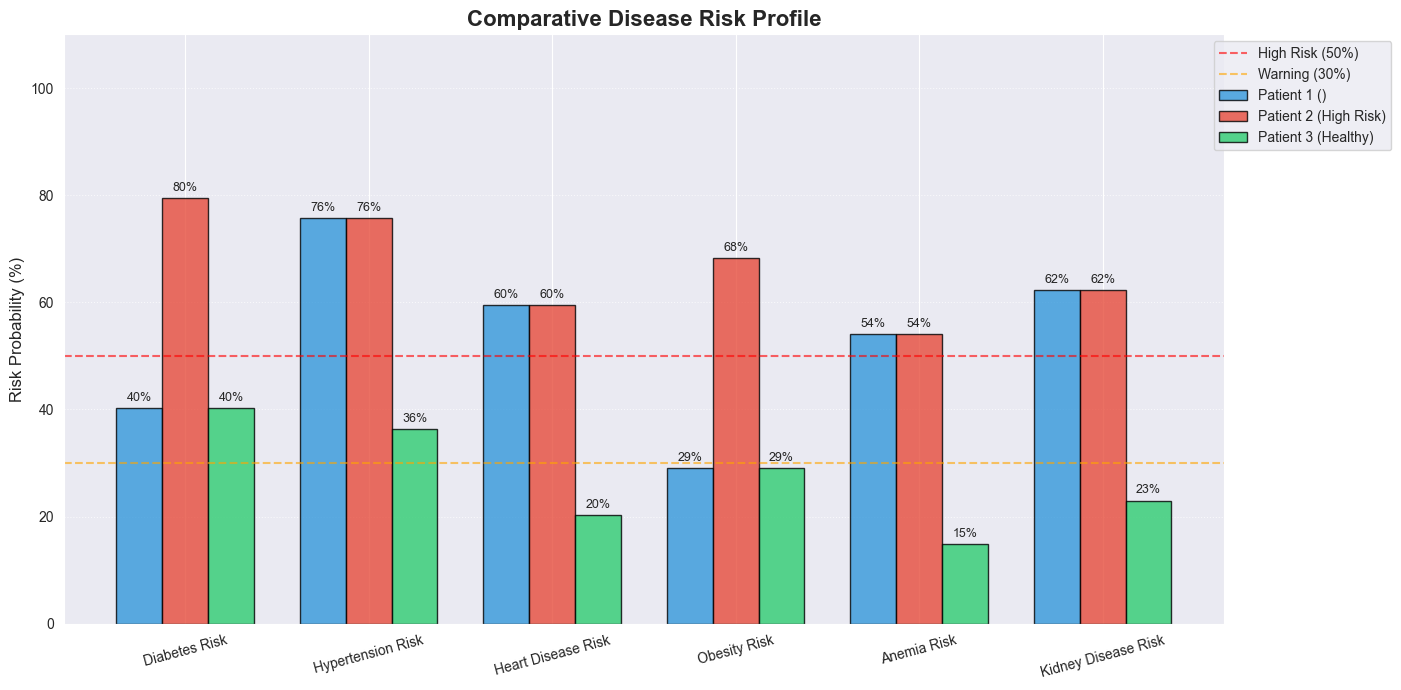

In [15]:
#import libraries
import pandas as pd
import numpy as np
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# --- 1. Load and Prepare Data ---
file_path = "health_nutrition_disease_dataset_12000.xlsx"
df = pd.read_excel(file_path)

# Encoding
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
disease_columns = ["Diabetes_Risk", "Hypertension_Risk", "Heart_Disease_Risk", "Obesity_Risk", "Anemia_Risk", "Kidney_Disease_Risk"]
for col in disease_columns:
    df[col] = df[col].map({"High": 1, "Low": 0})

features = ["Age", "Gender", "BMI", "Daily_Calories_kcal", "Carbohydrates_g", "Protein_g", "Total_Fat_g", 
            "Saturated_Fat_g", "Trans_Fat_g", "Total_Sugar_g", "Added_Sugar_g", "Fiber_g", "Sodium_mg", 
            "Potassium_mg", "Calcium_mg", "Iron_mg", "Vitamin_D_IU", "Vitamin_B12_mcg", "Physical_Activity_min", "Water_Intake_L"]

X = df[features]
X_train_raw, X_test_raw = train_test_split(X, test_size=0.2, random_state=42)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)
joblib.dump(scaler, "scaler.pkl")

# --- 2. Train Models with Anti-Overfitting Settings ---
models = {}
print("--- MODEL TRAINING PERFORMANCE ---")

for disease in disease_columns:
    y = df[disease]
    y_train, y_test = train_test_split(y, test_size=0.2, random_state=42)

    model = XGBClassifier(
    n_estimators=50,
    max_depth=2,
    scale_pos_weight=5,  # Forces the model to pay 5x more attention to High Risk cases
    learning_rate=0.01,    # Very slow learning for higher precision
    reg_alpha=5,            # L1 regularization to ignore "noisy" features
    reg_lambda=5,           # L2 regularization to smooth out predictions
    min_child_weight=10,    # Requires more patients to agree before making a rule
    eval_metric="logloss"
)
    model.fit(X_train_scaled, y_train)
    
    # Check for Overfitting
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    
    print(f"\nTarget: {disease}")
    print(f"Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f} (Gap: {train_acc-test_acc:.3f})")
    
    models[disease] = model
    joblib.dump(model, f"{disease}_model.pkl")
    

# --- 3. Run Predictions on Multiple Patients ---
def calculate_bmi(weight_kg, height_cm):
    return round(weight_kg / ((height_cm / 100) ** 2), 1)

# List of Dummy Patients
test_patients = [
    {"Name": "Patient 1 ()", "Age": 45, "Gender": 1, "Weight_kg": 70, "Height_cm": 154, "Daily_Calories_kcal": 2800, "Carbohydrates_g": 350, "Protein_g": 90, "Total_Fat_g": 130, "Saturated_Fat_g": 45, "Trans_Fat_g": 2, "Total_Sugar_g": 120, "Added_Sugar_g": 90, "Fiber_g": 15, "Sodium_mg": 3500, "Potassium_mg": 2000, "Calcium_mg": 500, "Iron_mg": 7, "Vitamin_D_IU": 2190, "Vitamin_B12_mcg": 1.8, "Physical_Activity_min": 20, "Water_Intake_L": 1.2},
    {"Name": "Patient 2 (High Risk)", "Age": 62, "Gender": 0, "Weight_kg": 95, "Height_cm": 170, "Daily_Calories_kcal": 3200, "Carbohydrates_g": 450, "Protein_g": 70, "Total_Fat_g": 140, "Saturated_Fat_g": 60, "Trans_Fat_g": 5, "Total_Sugar_g": 180, "Added_Sugar_g": 130, "Fiber_g": 10, "Sodium_mg": 4800, "Potassium_mg": 1500, "Calcium_mg": 400, "Iron_mg": 6, "Vitamin_D_IU": 800, "Vitamin_B12_mcg": 1.2, "Physical_Activity_min": 5, "Water_Intake_L": 0.8},
    {"Name": "Patient 3 (Healthy)", "Age": 28, "Gender": 1, "Weight_kg": 60, "Height_cm": 165, "Daily_Calories_kcal": 2100, "Carbohydrates_g": 250, "Protein_g": 120, "Total_Fat_g": 70, "Saturated_Fat_g": 15, "Trans_Fat_g": 0, "Total_Sugar_g": 40, "Added_Sugar_g": 10, "Fiber_g": 35, "Sodium_mg": 1800, "Potassium_mg": 3500, "Calcium_mg": 1200, "Iron_mg": 18, "Vitamin_D_IU": 4000, "Vitamin_B12_mcg": 4.5, "Physical_Activity_min": 90, "Water_Intake_L": 3.0}
]

print("\n" + "="*50 + "\nFINAL PREDICTIONS\n" + "="*50)

print("\n" + "="*60 + "\nDETAILED MEDICAL RISK REPORT\n" + "="*60)

for p in test_patients:
    # 1. Calculate and Store BMI
    bmi_value = calculate_bmi(p["Weight_kg"], p["Height_cm"])
    p["BMI"] = bmi_value
    
    # 2. Display BMI Context First
    print(f"\n>>> {p['Name']}")
    print(f"Calculated BMI : {bmi_value}")
    print(f"Normal Range   : 18.5 - 24.9")
    
    # Determine Clinical Category
    if bmi_value < 18.5:
        category = "Underweight"
    elif 18.5 <= bmi_value < 25:
        category = "Normal Weight"
    elif 25 <= bmi_value < 30:
        category = "Overweight (Pre-Obese)"
    else:
        category = "Obese"
    print(f"Clinical Status: {category}")
    print("-" * 30)

    # 3. Prepare data for model
    p_df = pd.DataFrame([{k: p[k] for k in features}])
    p_scaled = scaler.transform(p_df)
    
    # 4. Predict Disease Risks
    for disease in disease_columns:
        # Get the probability score
        prob = models[disease].predict_proba(p_scaled)[0][1] 
        
        # MEDICAL CALIBRATION: 
        # For Obesity and Heart Disease, we use a 30% threshold for early warning
        # For others, we use the standard 50%
        threshold = 0.30 if disease in ["Obesity_Risk", "Heart_Disease_Risk"] else 0.50
        
        if prob > threshold:
            status = " HIGH RISK"
        elif prob > 0.15:
            status = " MODERATE RISK"
        else:
            status = "LOW RISK"
            
        print(f"{disease.replace('_', ' '):<20}: {status} ({prob*100:.1f}%)")
        
        
        
        
        import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare Data for Plotting
patient_names = [p['Name'] for p in test_patients]
disease_labels = [d.replace('_', ' ') for d in disease_columns]
all_probs = []

# Collect probabilities for each patient
for p in test_patients:
    p_df = pd.DataFrame([{k: p[k] for k in features}])
    p_scaled = scaler.transform(p_df)
    probs = [models[d].predict_proba(p_scaled)[0][1] * 100 for d in disease_columns]
    all_probs.append(probs)

# 2. Setup Plot
x = np.arange(len(disease_labels))  # Label locations
width = 0.25  # Bar width
fig, ax = plt.subplots(figsize=(14, 7))

# Define colors for different patients
colors = ['#3498db', '#e74c3c', '#2ecc71'] # Blue, Red, Green

# 3. Create Bars
for i, probs in enumerate(all_probs):
    offset = (i - 1) * width  # Centers the groups
    rects = ax.bar(x + offset, probs, width, label=patient_names[i], color=colors[i], edgecolor='black', alpha=0.8)
    # Add percentage labels on top of bars
    ax.bar_label(rects, padding=3, fmt='%.0f%%', fontsize=9)

# 4. Add Medical Threshold Lines
ax.axhline(y=50, color='red', linestyle='--', alpha=0.6, label='High Risk (50%)')
ax.axhline(y=30, color='orange', linestyle='--', alpha=0.6, label='Warning (30%)')

# 5. Styling the Chart
ax.set_ylabel('Risk Probability (%)', fontsize=12)
ax.set_title('Comparative Disease Risk Profile', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(disease_labels, rotation=15)
ax.set_ylim(0, 110)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
ax.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()
       
   


>> RECOMMENDATIONS
Lifestyle : Maintain hydration.


Reccomandation Model 

--- TRAINING MODELS ---

DETAILED MEDICAL RISK & RECOMMENDATION REPORT

>>> Patient 1 (Moderate) (BMI: 29.5)
----------------------------------------
Diabetes Risk       :  [+] MODERATE RISK (40.3%)
Hypertension Risk   :  [!] HIGH RISK (75.7%)
Heart Disease Risk  :  [!] HIGH RISK (59.5%)
Obesity Risk        :  [+] MODERATE RISK (29.0%)
Anemia Risk         :  [!] HIGH RISK (54.0%)
Kidney Disease Risk :  [!] HIGH RISK (62.3%)

ACTIONABLE RECOMMENDATIONS:
- HYPERTENSION: Critical: Lower Sodium intake below 1500mg/day and increase Potassium.
- ANEMIA: Increase iron-rich foods (lean meats, spinach) and Vitamin C to aid absorption.
- HEART HEALTH: Swap saturated/trans fats for Omega-3 fatty acids (fish, walnuts).
- KIDNEY CARE: Increase water intake and monitor protein-to-sodium ratios closely.
------------------------------------------------------------

>>> Patient 2 (High Risk) (BMI: 32.9)
----------------------------------------
Diabetes Risk       :  [!] HIGH RISK (79.5%)
Hypertension R

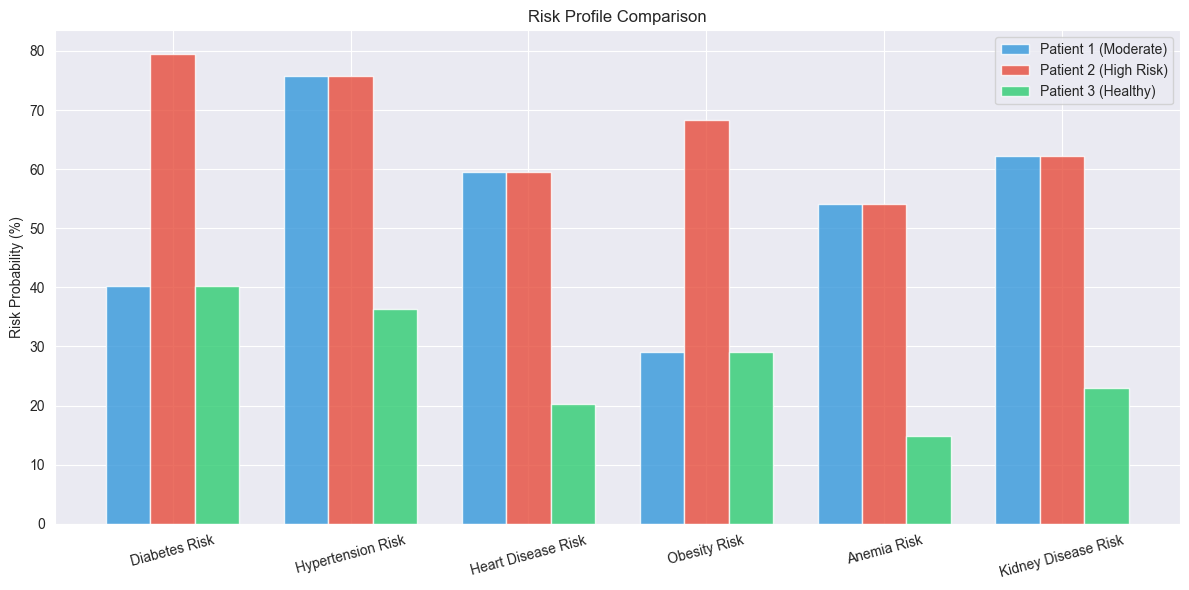

In [16]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# --- 1. Load and Prepare Data ---
# Note: Ensure your "health_nutrition_disease_dataset_12000.xlsx" is in the same directory
file_path = "health_nutrition_disease_dataset_12000.xlsx"
df = pd.read_excel(file_path)

# Encoding
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
disease_columns = ["Diabetes_Risk", "Hypertension_Risk", "Heart_Disease_Risk", "Obesity_Risk", "Anemia_Risk", "Kidney_Disease_Risk"]
for col in disease_columns:
    df[col] = df[col].map({"High": 1, "Low": 0})

features = ["Age", "Gender", "BMI", "Daily_Calories_kcal", "Carbohydrates_g", "Protein_g", "Total_Fat_g", 
            "Saturated_Fat_g", "Trans_Fat_g", "Total_Sugar_g", "Added_Sugar_g", "Fiber_g", "Sodium_mg", 
            "Potassium_mg", "Calcium_mg", "Iron_mg", "Vitamin_D_IU", "Vitamin_B12_mcg", "Physical_Activity_min", "Water_Intake_L"]

X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, "scaler.pkl")

# --- 2. Train Models ---
models = {}
print("--- TRAINING MODELS ---")

for disease in disease_columns:
    y = df[disease]
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    model = XGBClassifier(
        n_estimators=50, max_depth=2, scale_pos_weight=5,
        learning_rate=0.01, reg_alpha=5, reg_lambda=5,
        min_child_weight=10, eval_metric="logloss"
    )
    model.fit(X_train, y_train)
    models[disease] = model

# --- 3. Recommendation Logic Engine ---
def get_medical_recommendations(patient_data, risks):
    recs = []
    
    if "Diabetes_Risk" in risks and (patient_data['Added_Sugar_g'] > 50 or patient_data['Fiber_g'] < 25):
        recs.append("- DIABETES: Reduce added sugars (<25g/day) and increase Fiber to 30g+ to stabilize glucose.")
        
    if "Hypertension_Risk" in risks and patient_data['Sodium_mg'] > 2300:
        recs.append("- HYPERTENSION: Critical: Lower Sodium intake below 1500mg/day and increase Potassium.")
        
    if "Obesity_Risk" in risks:
        recs.append(f"- WEIGHT MGMT: Target a calorie deficit. Increase physical activity from {patient_data['Physical_Activity_min']}min to 150min/week.")
        
    if "Anemia_Risk" in risks and patient_data['Iron_mg'] < 12:
        recs.append("- ANEMIA: Increase iron-rich foods (lean meats, spinach) and Vitamin C to aid absorption.")
        
    if "Heart_Disease_Risk" in risks and (patient_data['Saturated_Fat_g'] > 20 or patient_data['Trans_Fat_g'] > 0):
        recs.append("- HEART HEALTH: Swap saturated/trans fats for Omega-3 fatty acids (fish, walnuts).")

    if "Kidney_Disease_Risk" in risks and patient_data['Water_Intake_L'] < 2.0:
        recs.append("- KIDNEY CARE: Increase water intake and monitor protein-to-sodium ratios closely.")

    return recs if recs else ["- Maintain current balanced lifestyle; continue regular checkups."]

# --- 4. Run Predictions & Display Reports ---
def calculate_bmi(weight_kg, height_cm):
    return round(weight_kg / ((height_cm / 100) ** 2), 1)

test_patients = [
    {"Name": "Patient 1 (Moderate)", "Age": 45, "Gender": 1, "Weight_kg": 70, "Height_cm": 154, "Daily_Calories_kcal": 2800, "Carbohydrates_g": 350, "Protein_g": 90, "Total_Fat_g": 130, "Saturated_Fat_g": 45, "Trans_Fat_g": 2, "Total_Sugar_g": 120, "Added_Sugar_g": 90, "Fiber_g": 15, "Sodium_mg": 3500, "Potassium_mg": 2000, "Calcium_mg": 500, "Iron_mg": 7, "Vitamin_D_IU": 2190, "Vitamin_B12_mcg": 1.8, "Physical_Activity_min": 20, "Water_Intake_L": 1.2},
    {"Name": "Patient 2 (High Risk)", "Age": 62, "Gender": 0, "Weight_kg": 95, "Height_cm": 170, "Daily_Calories_kcal": 3200, "Carbohydrates_g": 450, "Protein_g": 70, "Total_Fat_g": 140, "Saturated_Fat_g": 60, "Trans_Fat_g": 5, "Total_Sugar_g": 180, "Added_Sugar_g": 130, "Fiber_g": 10, "Sodium_mg": 4800, "Potassium_mg": 1500, "Calcium_mg": 400, "Iron_mg": 6, "Vitamin_D_IU": 800, "Vitamin_B12_mcg": 1.2, "Physical_Activity_min": 5, "Water_Intake_L": 0.8},
    {"Name": "Patient 3 (Healthy)", "Age": 28, "Gender": 1, "Weight_kg": 60, "Height_cm": 165, "Daily_Calories_kcal": 2100, "Carbohydrates_g": 250, "Protein_g": 120, "Total_Fat_g": 70, "Saturated_Fat_g": 15, "Trans_Fat_g": 0, "Total_Sugar_g": 40, "Added_Sugar_g": 10, "Fiber_g": 35, "Sodium_mg": 1800, "Potassium_mg": 3500, "Calcium_mg": 1200, "Iron_mg": 18, "Vitamin_D_IU": 4000, "Vitamin_B12_mcg": 4.5, "Physical_Activity_min": 90, "Water_Intake_L": 3.0}
]

print("\n" + "="*60 + "\nDETAILED MEDICAL RISK & RECOMMENDATION REPORT\n" + "="*60)

patient_results_for_plot = []

for p in test_patients:
    bmi_value = calculate_bmi(p["Weight_kg"], p["Height_cm"])
    p["BMI"] = bmi_value
    
    print(f"\n>>> {p['Name']} (BMI: {bmi_value})")
    print("-" * 40)

    p_df = pd.DataFrame([{k: p[k] for k in features}])
    p_scaled = scaler.transform(p_df)
    
    detected_risks = []
    current_patient_probs = []

    for disease in disease_columns:
        prob = models[disease].predict_proba(p_scaled)[0][1]
        current_patient_probs.append(prob * 100)
        
        threshold = 0.30 if disease in ["Obesity_Risk", "Heart_Disease_Risk"] else 0.50
        
        if prob > threshold:
            status = " [!] HIGH RISK"
            detected_risks.append(disease)
        elif prob > 0.15:
            status = " [+] MODERATE RISK"
        else:
            status = " [ ] LOW RISK"
            
        print(f"{disease.replace('_', ' '):<20}: {status} ({prob*100:.1f}%)")

    # --- Print Recommendations Section ---
    print("\nACTIONABLE RECOMMENDATIONS:")
    recommendations = get_medical_recommendations(p, detected_risks)
    for r in recommendations:
        print(r)
    print("-" * 60)
    
    patient_results_for_plot.append(current_patient_probs)

# --- 5. Visualization ---
disease_labels = [d.replace('_', ' ') for d in disease_columns]
x = np.arange(len(disease_labels))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, probs in enumerate(patient_results_for_plot):
    ax.bar(x + (i - 1) * width, probs, width, label=test_patients[i]['Name'], color=colors[i], alpha=0.8)

ax.set_ylabel('Risk Probability (%)')
ax.set_title('Risk Profile Comparison')
ax.set_xticks(x)
ax.set_xticklabels(disease_labels, rotation=15)
ax.legend()
plt.tight_layout()
plt.show()